# Fig 8: Timing of neural remapping and behavioral updates

Use factorized K-means to identify clusters of the pre-switch and post-swith maps,  \
then compute a distance score for every trial from each cluster,  \
then fit sigmoids to identify the remap trial as the inflection point.

Requires open source code by Alex Williams and Isabel Low used in  \
Low et al. Giocomo, 2021:
https://github.com/ahwillia/lvl

In [1]:
%matplotlib inline
# inline, widget

import math
import sys
import os
import pickle
import dill
import numpy as np
import scipy as sp
import pandas as pd
import copy
from datetime import datetime

from matplotlib import pyplot as plt
from matplotlib import cm
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
import seaborn as sns
sns.set_style("white")

from reward_relative import behavior as behav
from reward_relative import utilities as ut
from reward_relative import plotUtils as pt
from reward_relative import xcorr as xc
from reward_relative import spatial
from reward_relative import dayData as dd
from reward_relative import circ
from reward_relative import regression
from reward_relative import kMeansDistScore as kds
    
import TwoPUtils

import sklearn
from sklearn.impute import KNNImputer

# import dask
# from dask.diagnostics import ProgressBar
# from scipy.optimize import curve_fit

%load_ext autoreload
%autoreload 2

save_figures = False

In [2]:
from reward_relative.path_dict_firebird import path_dictionary as path_dict
# options: path_dict_josquin, path_dict_msosamac, path_dict_msosaexternal

In [3]:
path_dict

{'preprocessed_root': '/data/2P',
 'sbx_root': '/mnt/oak/InVivoDA/2P_Data',
 'gdrive_root': '/mnt/gdrive/2P_Data',
 'VR_Data': '/data/2P/VR_Data',
 'git_repo_root': '/home/mari/local_repos/2p_repos',
 'TwoPUtils': '/home/mari/local_repos/2p_repos/TwoPUtils',
 'home': '/home/mari',
 'fig_dir': '/data/2P/fig_scratch'}

In [4]:
# # make a month-year figdir and set fig params

fig_dir = ut.make_fig_dir(path_dict)
pt.set_fig_params(fontsize=12)

/data/2P/fig_scratch/Apr2025


## Load saved multiDayData

If you want to create a new multiDayData, use the notebook Run_dayData_class.ipynb and save the pickle first.

In [5]:
experiment = 'MetaLearn'
exp_days = [3, 5, 7, 8, 10, 12, 14]

max_anim_list = dd.max_anim_list(experiment,exp_days, year='combined')
ts_key = 'dff' # used to find place field peaks

    
dt = "202504" #"20240530-1141"

pkl_name = "m%s-%s_expdays%s_multiDayData_%s_%s.pickle" % (ut.get_mouse_number(max_anim_list[0]),
                                                           ut.get_mouse_number(
                                                               max_anim_list[-1]),
                                                           ut.make_day_tag(
                                                               exp_days),
                                                           ts_key,
                                                           dt)

pkl_path = os.path.join(path_dict['preprocessed_root'],'multiDayData',pkl_name)
print(pkl_path)
multiDayData = dill.load(open(pkl_path,"rb"))

include_ans = multiDayData[exp_days[-1]].circ_rel_stats_across_an['include_ans']
max_anim_list = sorted(np.unique(np.concatenate([multiDayData[day].anim_list
                                                     for day in exp_days])), 
                           key=len)

/data/2P/multiDayData/m2-19_expdays3-5-7-8-10-12-14_multiDayData_dff_202504.pickle


# Run KMeans and Distance score

Using Isabel/Alex distance score and fitting a sigmoid to compare timing of remapping vs. behavior

In [6]:
import sys
# add Alex's repo to path
sys.path.append("/home/mari/local_repos/lvl")
from lvl.factor_models import KMeans as lvl_kmeans
# from lvl.resamplers import RotationResampler
# from lvl.crossval import speckled_cv_scores 
# from sklearn.metrics import silhouette_samples, silhouette_score
from scipy.spatial.distance import pdist, squareform


## Run Kmeans and Distance Score

In [ ]:
include_ans = multiDayData[exp_days[0]].circ_rel_stats_across_an['include_ans']
# use Isabel distance score from PV corr matrix
# separately calc PV corr mat for RR cells
dist_score = {}
cell_masks = {}
ct_keys = ['RR', 'TR', 'nonRR', 'appear', 'all']
ct = 'RR'

max_k = 2  # set max k to examine for optimal clustering
# ^we expect 2 maps, pre- and post-switch. Eliminating sessions that have more than
# 2 detected did not change the results.

for day in exp_days:

    # we need to load the full session data
    use_anim_list = dd.define_anim_list(
        experiment, exp_day=day, year='combined')
    if np.any(np.isin(include_ans, use_anim_list)):
        multi_anim_sess = dd.load_multi_anim_sess(path_dict, day, use_anim_list,
                                                  params={'speed': '2',
                                                          'nperms': 100,
                                                          'baseline_method': 'maximin',
                                                          'ts_key': 'events'
                                                          }
                                                  )

    dist_score[day] = {}
    for an_i, an in enumerate(include_ans):
        dist_score[day][an] = {'lick': {},
                               'speed': {},
                               'pv': dict([(ct, {}) for ct in ct_keys]),
                               'cell_masks': {},
                               }

        # kmeans clustering on licking and speed
        licks = np.copy(multi_anim_sess[an]['sess'].vr_data['lick'].values)
        # first get rid of times where the capacative sensor got stuck
        licks, error_count = behav.correct_lick_sensor_error(
            licks, multi_anim_sess[an]['sess'].trial_start_inds,
            multi_anim_sess[an]['sess'].teleport_inds,
            correction_thr=0.35)
        multi_anim_sess[an]['sess'].add_timeseries(licks_adj=licks)
        multi_anim_sess[an]['sess'].add_pos_binned_trial_matrix(
            ['licks_adj'], 'pos', impute_nans=False)

        L = np.copy(multi_anim_sess[an]['sess'].trial_matrices['licks_adj'][0])

        L[np.isnan(L)] = 0

        # norm to max (scale between 0 and 1)
        L = (L - np.nanmin(L))/(np.nanmax(L) - np.nanmin(L))
        lick_sim = spatial.corr_mat(L)

        # kmeans for licking
        lick_model_kmeans = lvl_kmeans(n_components=2, n_restarts=100)
        lick_model_kmeans.fit(L)
        W_lick, H_lick = lick_model_kmeans.factors

        # expansion only needed if we make the corr mat with squareform (it will look the same)
        L = L[:, :, np.newaxis]
        # lick_sim_vec = np.abs(pdist(L.squeeze(), 'correlation')-1)
        # lick_sim = squareform(lick_sim_vec)

        # same for speed
        S = np.copy(multi_anim_sess[an]['sess'].trial_matrices['speed'][0])
        # impute nans from low sampling
        imputer = KNNImputer(n_neighbors=3)
        S = imputer.fit_transform(S)
        S = (S - np.nanmin(S))/(np.nanmax(S) - np.nanmin(S))
        speed_sim = spatial.corr_mat(S)
        # norm to max, kmeans
        speed_model_kmeans = lvl_kmeans(n_components=2, n_restarts=100)
        speed_model_kmeans.fit(S)
        W_speed, H_speed = speed_model_kmeans.factors
        S = S[:, :, np.newaxis]
        # speed_sim_vec = np.abs(pdist(S.squeeze(), 'correlation')-1)
        # speed_sim = squareform(speed_sim_vec)

        # set diagonal to nan for plotting
        lick_sim[np.eye(lick_sim.shape[0], lick_sim.shape[0]
                        ).astype(bool)] = np.nan
        speed_sim[np.eye(speed_sim.shape[0], speed_sim.shape[0]
                         ).astype(bool)] = np.nan

        # assign first cluster in session as zero, target cluster as 1 (last in session)
        most_freq_cluster_id = [np.argmax(np.bincount(W_lick[
            multiDayData[day].trial_dict[an]['trial_set0'], i].astype(int))
        ) for i in range(W_lick.shape[1])]
        zero_cluster = most_freq_cluster_id.index(0)
        # print('lick',zero_cluster)
        # if zero cluster position is not 0 (i.e. first), swap the order
        if zero_cluster != 0:
            print('swapping lick cluster')
            # flip map indices too
            W_lick = ~(W_lick.astype(bool))*1
            H_lick = np.flipud(H_lick)

        # assign first cluster in session as zero
        most_freq_cluster_id = [np.argmax(np.bincount(W_speed[
            multiDayData[day].trial_dict[an]['trial_set0'], i].astype(int))
        ) for i in range(W_speed.shape[1])]
        zero_cluster = most_freq_cluster_id.index(0)
        # if zero cluster position is not 0 (i.e. first), swap the order
        if zero_cluster != 0:
            print('swapping speed cluster')
            # flip map indices too
            W_speed = ~(W_speed.astype(bool))*1
            H_speed = np.flipud(H_speed)
        map_0_index = 0

        dist_score[day][an]['lick']['sim'] = lick_sim
        dist_score[day][an]['speed']['sim'] = speed_sim
        dist_score[day][an]['lick']['dist'] = kds.clu_distance_population(
            L, H_lick, map_0_index)
        dist_score[day][an]['speed']['dist'] = kds.clu_distance_population(
            S, H_speed, map_0_index)

        # fit sigmoids to licking and speed
        dist_score[day][an]['lick']['sigmoid'], dist_score[day][an]['lick']['remap_trial'] = regression.fit_sigmoid(
            dist_score[day][an]['lick']['dist'])
        dist_score[day][an]['speed']['sigmoid'], dist_score[day][an]['speed']['remap_trial'] = regression.fit_sigmoid(
            dist_score[day][an]['speed']['dist'])

        # get the cell IDs
        RR_masks = np.zeros(
            multiDayData[day].overall_place_cell_masks[an].shape).astype(bool)
        RR_masks[multiDayData[day].reward_rel_cell_ids[an]] = True
        TR_masks = np.copy(multiDayData[day].cell_class[an]['masks']['track'])
        # omit any overlap with RR cells
        TR_masks[RR_masks] = False
        nonRR_masks = np.copy(
            multiDayData[day].cell_class[an]['masks']['nonreward_remap'])
        nonRR_masks[RR_masks] = False
        appear_masks = np.copy(
            multiDayData[day].cell_class[an]['masks']['appear'])
        appear_masks[RR_masks] = False

        cell_masks = {'RR': RR_masks,
                      'TR': TR_masks,
                      'nonRR': nonRR_masks,
                      'appear': appear_masks,
                      'all': multiDayData[day].overall_place_cell_masks[an],
                      }

        dist_score[day][an]['cell_masks'] = cell_masks

        # get the events trial matrix, excluding slow movement speeds <2cm/s
        tm = TwoPUtils.spatial_analyses.trial_matrix(multi_anim_sess[an]['sess'].timeseries['events'].T,
                                                     multi_anim_sess[an]['sess'].vr_data['pos']._values,
                                                     multi_anim_sess[an]['sess'].trial_start_inds,
                                                     multi_anim_sess[an]['sess'].teleport_inds,
                                                     bin_size=10,
                                                     min_pos=0,
                                                     max_pos=450,
                                                     speed_thr=2,
                                                     speed=multi_anim_sess[an]['sess'].timeseries['speed'][0]
                                                     )

        # for each "celltype", get the correlation matrix and Kmeans clustering
        for ct in ct_keys:

            print(day, an, ct)
            cell_ids = np.where(cell_masks[ct])[0]

            Y_ = tm[0][:, :, cell_ids]

            # smooth lightly in position domain
            Y_[np.isnan(Y_)] = 0
            Y_ = ut.nansmooth(Y_, 1, axis=1, mode='nearest')

            # original corr mat before normalization
            Y_pv_corr = spatial.corr_mat(spatial.population_vector(Y_, axis=1))

            # normalize each cell to its max
            for c in range(Y_.shape[2]):
                # option to impute nans instead
                # imputer = KNNImputer(n_neighbors=3)
                # Y_[:,:,c] = imputer.fit_transform(Y_[:,:,c])
                Y_[:, :, c] = (Y_[:, :, c] - np.nanmin(Y_[:, :, c])
                               )/(np.nanmax(Y_[:, :, c]) - np.nanmin(Y_[:, :, c]))

            best_k, r2, one_map = kds.optimal_k(Y_,  max_k=max_k,
                                                k_reps=20, shuffle_reps=50,
                                                alpha=0.05, verbose=True,
                                                shuffle_method='lvl')  # method = 'lvl' or 'manual'
            print('done with pv shuffle')

            # unwrap for k-means clustering below
            Y_unwrapped = Y_.transpose(0, 2, 1).reshape((Y_.shape[0], -1))

            # Y_sim_vec = np.abs(pdist(Y_unwrapped, 'correlation')-1)
            # Y_sim = squareform(Y_sim_vec)
            Y_sim = spatial.corr_mat(spatial.population_vector(Y_, axis=1))

            # for plotting, nan out diagonal
            Y_pv_corr[np.eye(Y_pv_corr.shape[0],
                             Y_pv_corr.shape[0]).astype(bool)] = np.nan
            Y_sim[np.eye(Y_sim.shape[0], Y_sim.shape[0]).astype(bool)] = np.nan

            # max normalized first
            dist_score[day][an]['pv'][ct]['sim'] = Y_sim
            dist_score[day][an]['pv'][ct]['corr_mat'] = Y_pv_corr
            dist_score[day][an]['pv'][ct]['k'] = best_k
            dist_score[day][an]['pv'][ct]['kmeans_r2'] = r2
            dist_score[day][an]['pv'][ct]['one_map'] = one_map

            # force 2 clusters -- could also take the best k if we wanted to look for more maps
            if one_map[0] == False:

                # To-do: streamline -- currently the model fit is also happening in kds.optimal_k to
                # compare to shuffle - could just output model fit from there to save time, though that
                # fit is happening at the "optimal k" which could be >2 if you're exploring other k,
                # where here it is forced to be 2
                model_kmeans = lvl_kmeans(n_components=2, n_restarts=100)
                model_kmeans.fit(Y_unwrapped)  # Y_pv_corr)
                W, H = model_kmeans.factors

                # assign first cluster in session as zero
                most_freq_cluster_id = [np.argmax(np.bincount(W[
                    multiDayData[day].trial_dict[an]['trial_set0'], i].astype(int))
                ) for i in range(W.shape[1])]
                zero_cluster = most_freq_cluster_id.index(0)
                # if zero cluster position is not 0 (i.e. first), swap the order
                if zero_cluster != 0:
                    print('swapping neural cluster')
                    # flip map indices too
                    W = ~(W.astype(bool))*1
                    H = np.flipud(H)
                map_0_index = 0

                # calculate distance to cluster for full population
                dist_score[day][an]['pv'][ct]['dist'] = kds.clu_distance_population(
                    Y_, H, map_0_index)

                # Fit a sigmoid to the distance score and find the inflection point (the "remap" trial)
                dist_score[day][an]['pv'][ct]['sigmoid'], dist_score[day][an]['pv'][ct]['remap_trial'] = regression.fit_sigmoid(
                    dist_score[day][an]['pv'][ct]['dist'])
            else:
                dist_score[day][an]['pv'][ct]['dist'] = np.asarray(np.nan)
                dist_score[day][an]['pv'][ct]['sigmoid'] = np.asarray(np.nan)
                dist_score[day][an]['pv'][ct]['remap_trial'] = np.asarray(
                    np.nan)

In [ ]:
dist_score.keys()

### Save or load previously saved model run

In [ ]:
# save dist score pickle
from datetime import datetime
pkl_name = 'allSwitchAns_days%s_%s_DistScore_smEvents_unsmDist_resampled_%s.pickle' % (
                    ut.make_day_tag(exp_days), '-'.join([ct for ct in ct_keys]), datetime.now().strftime("%Y%m%d-%H%M"))
save_ds = open(os.path.join(path_dict['preprocessed_root'], 'pickle_scratch', pkl_name), "wb")
dill.dump(dist_score, save_ds)

In [7]:
# load from pickle
## 20240805-1500 is the data used for figures
dt = '20240805-1500'
ct_keys = ['RR','TR','nonRR','appear','all']
pkl_name = 'allSwitchAns_days%s_%s_DistScore_smEvents_unsmDist_resampled_%s.pickle' % (
                    ut.make_day_tag(exp_days), '-'.join([ct for ct in ct_keys]), dt)
dist_score = dill.load(open(os.path.join(path_dict['preprocessed_root'], 'pickle_scratch', pkl_name), "rb"))

In [8]:
dist_score[3]['GCAMP3']['pv']['RR'].keys()

dict_keys(['sim', 'corr_mat', 'k', 'kmeans_r2', 'one_map', 'dist', 'sigmoid', 'remap_trial'])

In [9]:
## how many sessions did we exclude for having one map?
is_one_map = []
for day in exp_days:
    for an in include_ans:
        if dist_score[day][an]['pv']['RR']['one_map'][0]:
            is_one_map.append(1)
        else:
            is_one_map.append(0)
            
print(f"{len(is_one_map) - np.sum(is_one_map)} sessions accepted as k=2 out of {len(is_one_map)}")

50 sessions accepted as k=2 out of 77


## Plot correlation matrices and sigmoids for a given cell type (Fig. 8a-d)

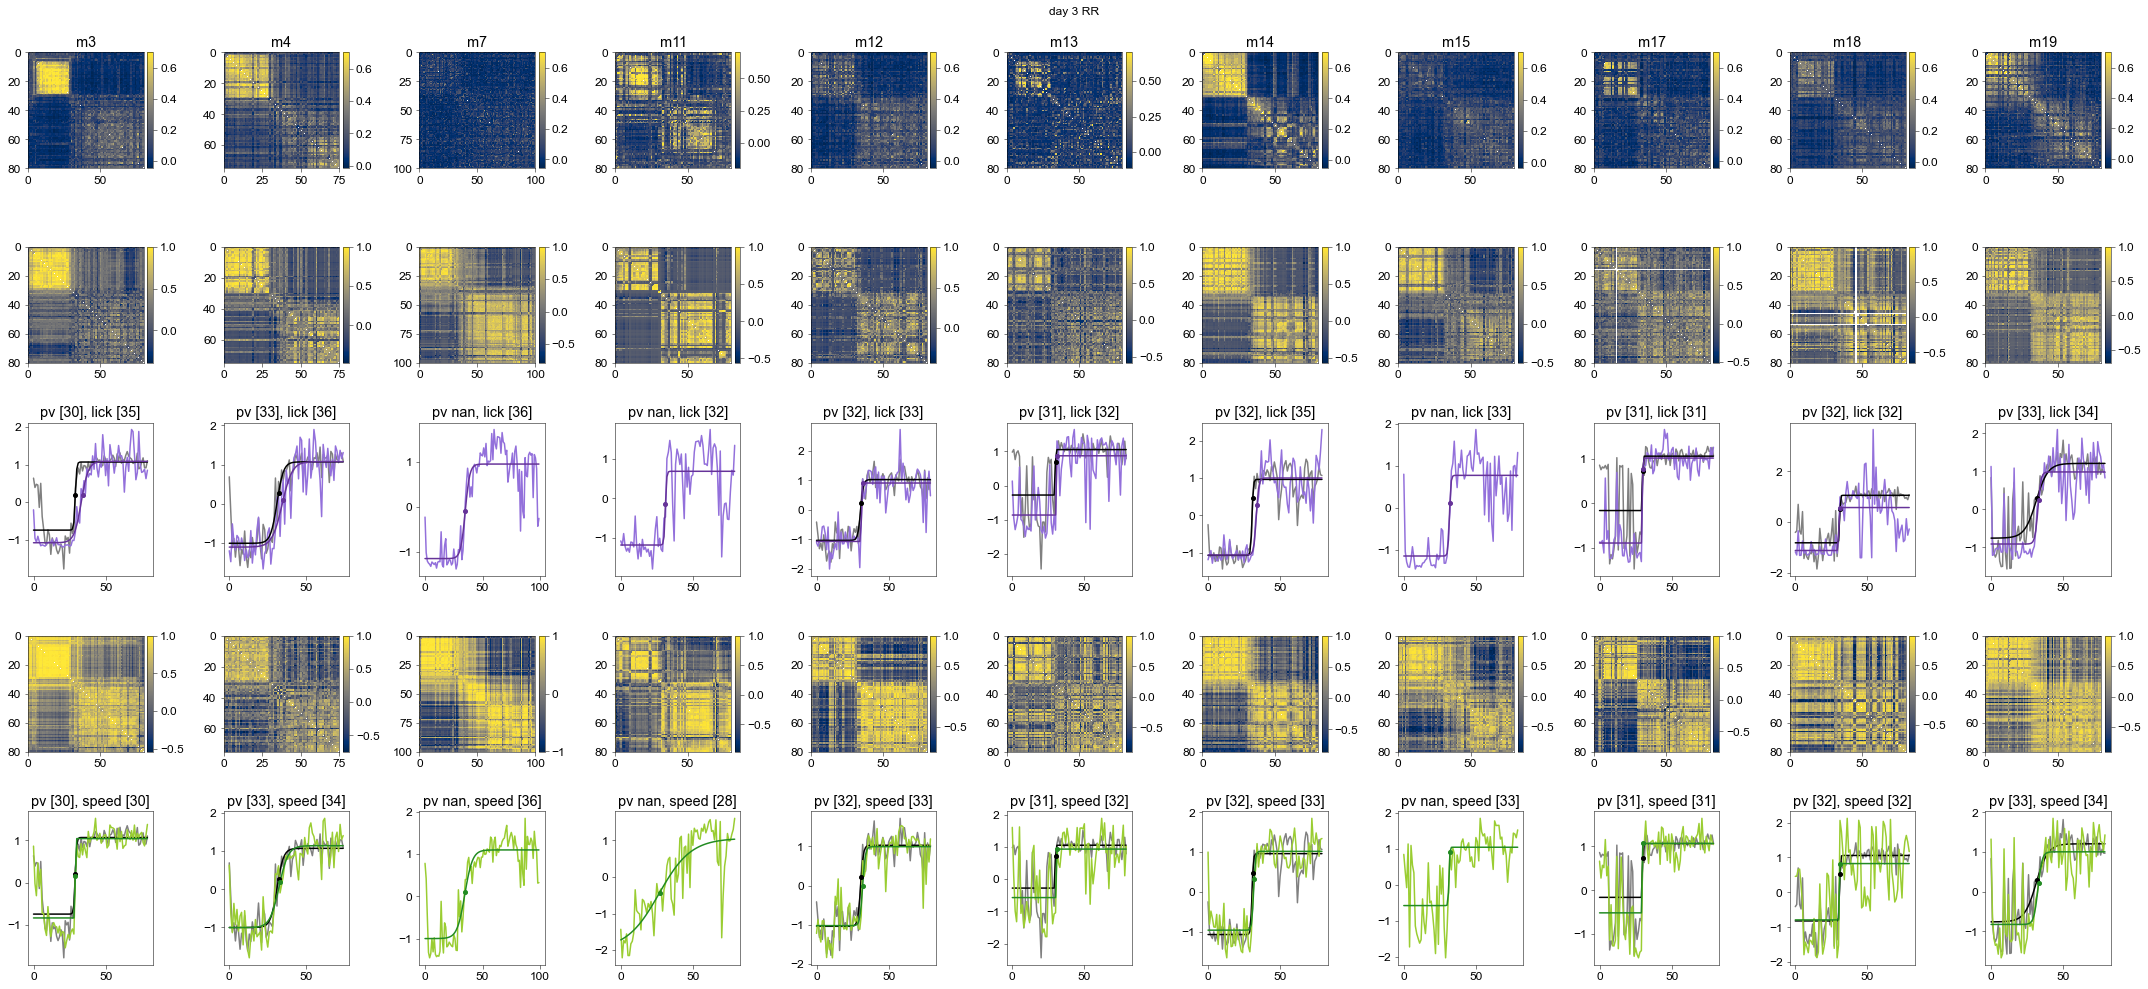

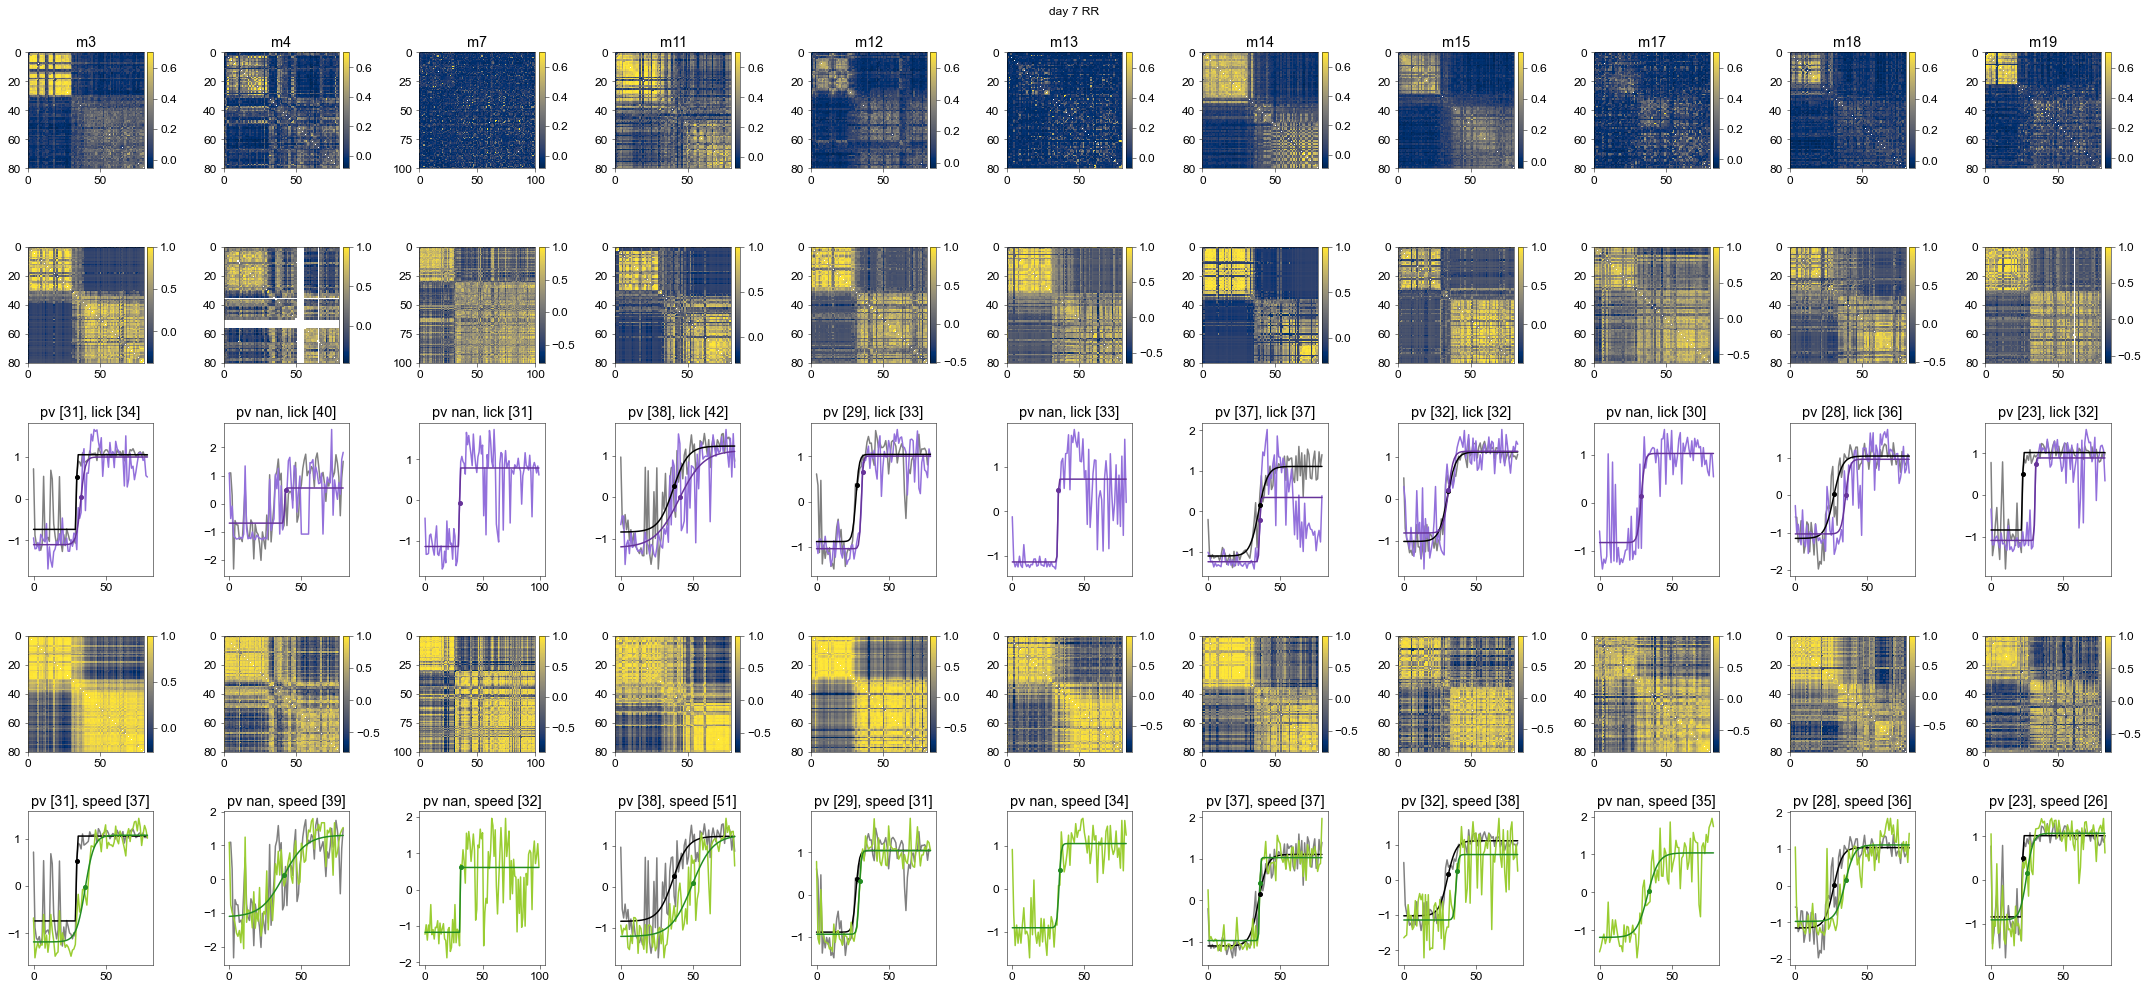

In [13]:
# Plot only, from loaded pickle

include_ans = multiDayData[exp_days[0]].circ_rel_stats_across_an['include_ans']

cell_masks = {}
# ,'TR','nonRR', 'appear','all']#['RR','TR','nonRR','appear','disappear']
ct_keys = ['RR']

for day in [3, 7]:  # dist_score.keys():

    use_anim_list = dd.define_anim_list(
        experiment, exp_day=day, year='combined')

    for ct in ct_keys:
        fig, ax = plt.subplots(5, len(include_ans), figsize=(30, 14))
        fig.suptitle(f"day {day} {ct}")
        # dist_score[day][ct] = {}
        for an_i, an in enumerate(dist_score[day].keys()):

            Y_sim = dist_score[day][an]['pv'][ct]['sim']
            lick_sim = dist_score[day][an]['lick']['sim']
            speed_sim = dist_score[day][an]['speed']['sim']

            # plot the corr matrices -- using pcolormesh instead of imshow
            # because it doesn't do weird things with the nans on the diagonal
            
            # sim mat just for RR cells; Y_sim
            h0 = ax[0, an_i].pcolormesh(
                Y_sim, shading='auto', vmax=0.7, cmap='cividis')

            ax[0, an_i].set_title(
                f"k={dist_score[day][an]['pv'][ct]['k']}, one_map={dist_score[day][an]['pv'][ct]['one_map'][0]}")

            # sim mat for licks; lick mat
            h1 = ax[1, an_i].pcolormesh(
                lick_sim, shading='auto',  vmax=1, cmap='cividis')

            # sim mat for licks; lick mat
            h2 = ax[3, an_i].pcolormesh(
                speed_sim, shading='auto', vmax=1, cmap='cividis')
            pt.colorbar(h0), pt.colorbar(h1), pt.colorbar(h2), pt.colorbar(h4)

            [ax[i, an_i].axis('square') for i in [0, 1, 3]]
            [ax[i, an_i].invert_yaxis() for i in [0, 1, 3]]

            # distance score for cells vs lick
            ax[2, an_i].plot(dist_score[day][an]['pv'][ct]['dist'], 'grey')
            ax[2, an_i].plot(dist_score[day][an]['lick']['dist'],
                             'mediumpurple')  # distance score for licks
            ax[2, an_i].plot(dist_score[day][an]['pv'][ct]['sigmoid'], 'black')
            ax[2, an_i].plot(dist_score[day][an]['lick']
                             ['sigmoid'], 'rebeccapurple')
            
            # add 1 to remap trial to convert to 1-indexing
            ax[2, an_i].set_title(
                f"pv {dist_score[day][an]['pv'][ct]['remap_trial']+1}, lick {dist_score[day][an]['lick']['remap_trial']+1}")
            
            # distance score for cells vs speed
            ax[4, an_i].plot(dist_score[day][an]['pv'][ct]['dist'], 'grey')
            ax[4, an_i].plot(dist_score[day][an]['pv'][ct]['sigmoid'], 'black')
            ax[4, an_i].plot(dist_score[day][an]['speed']['dist'],
                             'yellowgreen')  # distance score for speed
            ax[4, an_i].plot(dist_score[day][an]['speed']['sigmoid'],
                             color='forestgreen')  # sigmoid for speed
            
            ax[4, an_i].set_title(
                f"pv {dist_score[day][an]['pv'][ct]['remap_trial']+1}, speed {dist_score[day][an]['speed']['remap_trial']+1}")

            # plot sigmoids
            if ~np.isnan(dist_score[day][an]['pv'][ct]['remap_trial']):
                ax[2, an_i].plot(dist_score[day][an]['pv'][ct]['remap_trial'],
                                 dist_score[day][an]['pv'][ct]['sigmoid'][dist_score[day]
                                                                          [an]['pv'][ct]['remap_trial']],
                                 '.k', markersize=8)
                ax[4, an_i].plot(dist_score[day][an]['pv'][ct]['remap_trial'],
                                 dist_score[day][an]['pv'][ct]['sigmoid'][dist_score[day]
                                                                          [an]['pv'][ct]['remap_trial']],
                                 '.k', markersize=8)
            if ~np.isnan(dist_score[day][an]['lick']['remap_trial']):
                ax[2, an_i].plot(dist_score[day][an]['lick']['remap_trial'],
                                 dist_score[day][an]['lick']['sigmoid'][dist_score[day]
                                                                        [an]['lick']['remap_trial']],
                                 '.', color='rebeccapurple', markersize=8)
            
            if ~np.isnan(dist_score[day][an]['speed']['remap_trial']):
                ax[4, an_i].plot(dist_score[day][an]['speed']['remap_trial'],
                                 dist_score[day][an]['speed']['sigmoid'][dist_score[day]
                                                                         [an]['speed']['remap_trial']],
                                 '.', color='forestgreen', markersize=8)

            ax[0, an_i].set_title("m%s" % ut.get_mouse_number(an))

        save_figures = False
        if save_figures:
            pt.savefig(fig, fig_dir, 'allSwitchAns_days%d_%s_CorrMat_DistScore_resampled' % (
                day, ct),
                extension='.pdf')

In [18]:
# only for sessions with a successful sigmoidal fit,
# look at the distribution of remap trials
cols = ['mouse',
        'day',
        'switch',
        'env',
        'ct',
        'sess_id',
        'switch_dir',
        'datatype',
        'remap_trial',
        'diff_lick_pv',
        'diff_speed_pv',
        'lickratio',
        'k',
        'one_map']
sigmoid_df = pd.DataFrame(columns=cols)

ct_keys = ['RR','nonRR', 'appear']

for d_i, day in enumerate(dist_score.keys()):

    for an in include_ans:
        for ct in ct_keys:
            # check if remap trials are nan or empty
            # pv needs to be significantly non one-map
            if ~dist_score[day][an]['pv'][ct]['one_map'][0].astype(bool):
                accept_this_sess = (np.any(~np.isnan(dist_score[day][an]['pv'][ct]['remap_trial'])) &
                                    np.any(~np.isnan(dist_score[day][an]['lick']['remap_trial'])) &
                                    np.any(~np.isnan(dist_score[day][an]['speed']['remap_trial'])) 
                                   )
                if accept_this_sess:

                    this_df = pd.DataFrame(data=np.zeros(
                        (3, len(cols)))*np.nan, columns=cols)
                    this_df['mouse'] = np.repeat(an, 3)
                    this_df['day'] = np.repeat(day, 3)
                    this_df['switch'] = np.repeat(float(d_i+1), 3)
                    this_df['ct'] = np.repeat(ct, 3)

                    if multiDayData[day].rzone_pos[an]['set 1'][0] > multiDayData[day].rzone_pos[an]['set 0'][0]:
                        switch_dir = 'forward'
                    elif multiDayData[day].rzone_pos[an]['set 1'][0] < multiDayData[day].rzone_pos[an]['set 0'][0]:
                        switch_dir = 'backward'
                    else:
                        switch_dir = 'none'
                    if day in [3,5,7,10,12,14]:
                        env = 'fam'
                    elif day == 8:
                        env = 'novel'

                    this_df['switch_dir'] = np.repeat(switch_dir, 3)
                    this_df['sess_id'] = np.repeat((an + '_' + str(day)), 3)
                    this_df['env'] = np.repeat(env, 3)

                    this_df['datatype'] = ['pv',  'lick', 'speed']
                   
                    # remap trial: convert to 1 indexing
                    this_df['remap_trial'].loc[this_df['datatype'] ==
                                               'pv'] = dist_score[day][an]['pv'][ct]['remap_trial']+1
                    this_df['remap_trial'].loc[this_df['datatype'] ==
                                               'lick'] = dist_score[day][an]['lick']['remap_trial']+1
                    this_df['remap_trial'].loc[this_df['datatype'] ==
                                               'speed'] = dist_score[day][an]['speed']['remap_trial']+1
                    this_df['diff_lick_pv'].loc[this_df['datatype'] == 'lick'] = dist_score[day][an][
                        'lick']['remap_trial'] - dist_score[day][an]['pv'][ct]['remap_trial']
                    this_df['diff_speed_pv'].loc[this_df['datatype'] == 'speed'] = dist_score[day][an][
                        'speed']['remap_trial'] - dist_score[day][an]['pv'][ct]['remap_trial']
                    this_df['lickratio'] = np.repeat(np.nanmean(
                        multiDayData[day].in_vs_out_lickratio[an]['set 1'][:50]), 3)
                    this_df['k'].loc[this_df['datatype'] ==
                                     'pv'] = dist_score[day][an]['pv'][ct]['k']
                    this_df['one_map'].loc[this_df['datatype'] ==
                                           'pv'] = dist_score[day][an]['pv'][ct]['one_map'][0].astype(bool)
                    sigmoid_df = sigmoid_df.append(this_df, ignore_index=True)


/home/mari/anaconda3/envs/dope2p_rr/lib/python3.8/site-packages/pandas/core/indexing.py:670: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  iloc._setitem_with_indexer(indexer, value)


In [19]:
sigmoid_df

,mouse,day,switch,env,ct,sess_id,switch_dir,datatype,remap_trial,diff_lick_pv,diff_speed_pv,lickratio,k,one_map
0,GCAMP3,3,1.0,fam,RR,GCAMP3_3,backward,pv,30.0,NaN,NaN,0.213336,2.0,False
1,GCAMP3,3,1.0,fam,RR,GCAMP3_3,backward,lick,35.0,5.0,NaN,0.213336,NaN,NaN
2,GCAMP3,3,1.0,fam,RR,GCAMP3_3,backward,speed,30.0,NaN,0.0,0.213336,NaN,NaN
3,GCAMP3,3,1.0,fam,nonRR,GCAMP3_3,backward,pv,30.0,NaN,NaN,0.213336,2.0,False
4,GCAMP3,3,1.0,fam,nonRR,GCAMP3_3,backward,lick,35.0,5.0,NaN,0.213336,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
328,GCAMP18,14,7.0,fam,nonRR,GCAMP18_14,forward,lick,33.0,2.0,NaN,0.518300,NaN,NaN
329,GCAMP18,14,7.0,fam,nonRR,GCAMP18_14,forward,speed,33.0,NaN,2.0,0.518300,NaN,NaN
330,GCAMP18,14,7.0,fam,appear,GCAMP18_14,forward,pv,45.0,NaN,NaN,0.518300,2.0,False
331,GCAMP18,14,7.0,fam,appear,GCAMP18_14,forward,lick,33.0,-12.0,NaN,0.518300,NaN,NaN


In [53]:
rr_df = sigmoid_df[['mouse','day','switch','ct','sess_id','switch_dir','datatype','remap_trial']]
rr_df = rr_df[(rr_df['ct']=='RR')]

nonrr_df = sigmoid_df[['mouse','day','switch','ct','sess_id','switch_dir','datatype','remap_trial']]
nonrr_df = nonrr_df[(nonrr_df['ct']=='nonRR')]

appear_df = sigmoid_df[['mouse','day','switch','ct','sess_id','switch_dir','datatype','remap_trial']]
appear_df = appear_df[(appear_df['ct']=='appear')]

ct_df = sigmoid_df[['mouse','day','switch','ct','sess_id','switch_dir','datatype','remap_trial']]
ct_df = ct_df[ct_df['datatype']=='pv']
ct_df

,mouse,day,switch,ct,sess_id,switch_dir,datatype,remap_trial
0,GCAMP3,3,1.0,RR,GCAMP3_3,backward,pv,30.0
3,GCAMP3,3,1.0,nonRR,GCAMP3_3,backward,pv,30.0
6,GCAMP4,3,1.0,RR,GCAMP4_3,backward,pv,33.0
9,GCAMP4,3,1.0,nonRR,GCAMP4_3,backward,pv,32.0
12,GCAMP12,3,1.0,RR,GCAMP12_3,forward,pv,32.0
...,...,...,...,...,...,...,...,...
318,GCAMP15,14,7.0,nonRR,GCAMP15_14,forward,pv,31.0
321,GCAMP17,14,7.0,appear,GCAMP17_14,backward,pv,38.0
324,GCAMP18,14,7.0,RR,GCAMP18_14,forward,pv,33.0
327,GCAMP18,14,7.0,nonRR,GCAMP18_14,forward,pv,31.0


In [54]:
# ut.write_source_csv(rr_df, '8e')
# ut.write_source_csv(nonrr_df, 'Ext10e')
# ut.write_source_csv(appear_df, 'Ext10f')
# ut.write_source_csv(ct_df, 'Ext10g')

writing /data/2P/source_data/Fig8e.csv
writing /data/2P/source_data/FigExt10e.csv
writing /data/2P/source_data/FigExt10f.csv
writing /data/2P/source_data/FigExt10g.csv


#### Comparing remapping trial between cell types: Ext Fig. 10g

In [24]:
palette = {'RR': 'orange',
               'TR': 'black',
               'nonRR': 'grey',
               'appear': 'brown'
              }
    
get_palette = {}
[get_palette.update({cat: palette[cat]})for cat in ct_keys]
get_palette

{'RR': 'orange', 'nonRR': 'grey', 'appear': 'brown'}

In [25]:
# print mean and std across populations
print('RR:', sigmoid_df[(sigmoid_df['datatype']=='pv') & (sigmoid_df['ct']=='RR')]['remap_trial'].mean(),
    sigmoid_df[(sigmoid_df['datatype']=='pv') & (sigmoid_df['ct']=='RR')]['remap_trial'].std())
print('TR:', sigmoid_df[(sigmoid_df['datatype']=='pv') & (sigmoid_df['ct']=='TR')]['remap_trial'].mean(),
    sigmoid_df[(sigmoid_df['datatype']=='pv') & (sigmoid_df['ct']=='TR')]['remap_trial'].std())
print('nonRR:', sigmoid_df[(sigmoid_df['datatype']=='pv') & (sigmoid_df['ct']=='nonRR')]['remap_trial'].mean(),
    sigmoid_df[(sigmoid_df['datatype']=='pv') & (sigmoid_df['ct']=='nonRR')]['remap_trial'].std())
print('appear:', sigmoid_df[(sigmoid_df['datatype']=='pv') & (sigmoid_df['ct']=='appear')]['remap_trial'].mean(),
    sigmoid_df[(sigmoid_df['datatype']=='pv') & (sigmoid_df['ct']=='appear')]['remap_trial'].std())

RR: 31.91304347826087 2.374176694318562
TR: nan nan
nonRR: 32.86046511627907 3.9132339284172697
appear: 43.0 7.217703103843916


In [37]:
import pingouin

/home/mari/anaconda3/envs/dope2p_rr/lib/python3.8/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.0, the latest is 0.5.5.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(
/home/mari/anaconda3/envs/dope2p_rr/lib/python3.8/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package outdated is out of date. Your version is 0.2.1, the latest is 0.2.2.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


                               Mixed Linear Model Regression Results
Model:                           MixedLM               Dependent Variable:               remap_trial
No. Observations:                111                   Method:                           REML       
No. Groups:                      11                    Scale:                            14.3026    
Min. group size:                 1                     Log-Likelihood:                   -310.8170  
Max. group size:                 18                    Converged:                        Yes        
Mean group size:                 10.1                                                               
----------------------------------------------------------------------------------------------------
                                                          Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------------------------------------------
Intercept             

/home/mari/anaconda3/envs/dope2p_rr/lib/python3.8/site-packages/IPython/core/pylabtools.py:132: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations. 
  fig.canvas.print_figure(bytes_io, **kw)


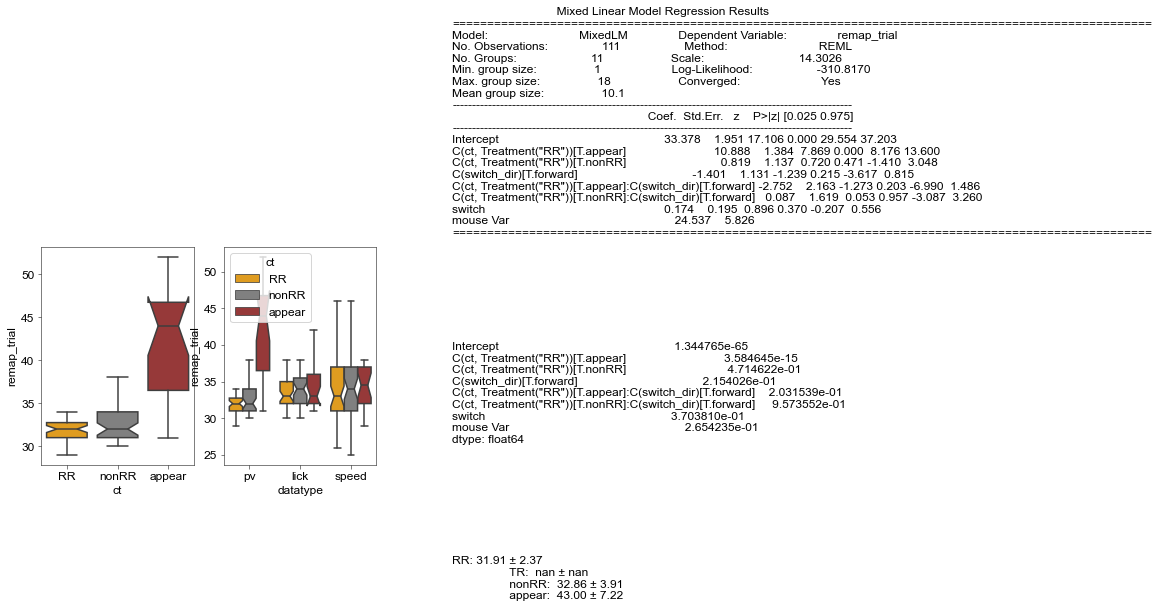

In [68]:
# by cell type
mean_std_str = "RR: %.2f ± %.2f \n \
                TR:  %.2f ± %.2f \n \
                nonRR:  %.2f ± %.2f \n \
                appear:  %.2f ± %.2f" % (sigmoid_df[
    (sigmoid_df['datatype']=='pv') & (sigmoid_df['ct']=='RR')]['remap_trial'].mean(),
    sigmoid_df[(sigmoid_df['datatype']=='pv') & (sigmoid_df['ct']=='RR')]['remap_trial'].std(),
    sigmoid_df[(sigmoid_df['datatype']=='pv') & (sigmoid_df['ct']=='TR')]['remap_trial'].mean(),
    sigmoid_df[(sigmoid_df['datatype']=='pv') & (sigmoid_df['ct']=='TR')]['remap_trial'].std(),
    sigmoid_df[(sigmoid_df['datatype']=='pv') & (sigmoid_df['ct']=='nonRR')]['remap_trial'].mean(),
    sigmoid_df[(sigmoid_df['datatype']=='pv') & (sigmoid_df['ct']=='nonRR')]['remap_trial'].std(),
    sigmoid_df[(sigmoid_df['datatype']=='pv') & (sigmoid_df['ct']=='appear')]['remap_trial'].mean(),
    sigmoid_df[(sigmoid_df['datatype']=='pv') & (sigmoid_df['ct']=='appear')]['remap_trial'].std())


fig,ax = plt.subplots(1,2)
sns.boxplot(data=sigmoid_df[sigmoid_df['datatype']=='pv'], x='ct', y='remap_trial', ax=ax[0], notch=True, 
            palette = pt.ct_palette(ct_keys),
           showfliers=False)
sns.boxplot(data=sigmoid_df, x='datatype', y='remap_trial', hue = 'ct', ax=ax[1], notch=True, 
            palette = pt.ct_palette(ct_keys),
           showfliers=False)

lmm_ct = smf.mixedlm('remap_trial ~ 1 + C(ct, Treatment("RR"))*C(switch_dir) + switch', groups='mouse',
                   re_formula='1', 
                   data=sigmoid_df[sigmoid_df['datatype']=='pv']).fit(reml=True)
print(lmm_ct.summary())
print(lmm_ct.wald_test_terms())
ax[1].text(4, ax[1].get_ylim()[-1], lmm_ct.summary().as_text());
ax[1].text(4, ax[1].get_ylim()[-1]-0.5*ax[1].get_ylim()[-1], str(lmm_ct.pvalues));
ax[1].text(4, ax[1].get_ylim()[-1]-0.9*ax[1].get_ylim()[-1], mean_std_str)

save_figures = False
if save_figures:
    pt.savefig(fig, fig_dir, 'allSwitchAns_days%d-%d_%s_DistScore_RemapTrial-by-ct-Box_smEvents_update' % (
            exp_days[0], exp_days[-1], '-'.join([ct for ct in ct_keys])),
                   extension='.svg')

In [43]:
#Much simpler method to compare celltypes and correct for multiple comparisons:
pingouin.pairwise_ttests(data=sigmoid_df, dv='remap_trial', within='ct', subject='sess_id', parametric=False,
                         padjust='bonferroni')

/home/mari/anaconda3/envs/dope2p_rr/lib/python3.8/site-packages/scipy/stats/morestats.py:3141: UserWarning: Exact p-value calculation does not work if there are ties. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "


,Contrast,A,B,Paired,Parametric,W-val,alternative,p-unc,p-corr,p-adjust,hedges
0,ct,RR,appear,True,False,1.0,two-sided,0.000061,0.000183,bonferroni,-0.906415
1,ct,RR,nonRR,True,False,39.5,two-sided,0.253485,0.760455,bonferroni,-0.069523
2,ct,appear,nonRR,True,False,0.0,two-sided,0.000721,0.002163,bonferroni,0.775074


In [166]:
lmm_ct.pvalues[1:-1]

C(ct, Treatment("RR"))[T.appear]                             3.584645e-15
C(ct, Treatment("RR"))[T.nonRR]                              4.714622e-01
C(switch_dir)[T.forward]                                     2.154026e-01
C(ct, Treatment("RR"))[T.appear]:C(switch_dir)[T.forward]    2.031539e-01
C(ct, Treatment("RR"))[T.nonRR]:C(switch_dir)[T.forward]     9.573552e-01
switch                                                       3.703810e-01
dtype: float64

In [100]:
# multiple comparison correction for fixed effect pvalues:
pvals = lmm_ct.pvalues[1:-1].values
from statsmodels.stats.multitest import multipletests
_, adj_pvals, _, _ = multipletests(pvals, method='fdr_bh')

adj_pvals

array([2.15078678e-14, 5.65754651e-01, 4.30805206e-01, 4.30805206e-01,
       9.57355167e-01, 5.55571506e-01])

In [104]:
ser = pd.concat([pd.Series(lmm_ct.fe_params[1:].values), pd.Series(adj_pvals)], axis=1) #, index=lmm_ct.fe_params[1:].index)
ser['fe'] = lmm_ct.fe_params[1:].index
ser
# pd.DataFrame(data=ser, columns=['coef','pval'], index=lmm_ct.fe_params[1:].index)

,0,1,fe
0,10.887615,2.150787e-14,"C(ct, Treatment(""RR""))[T.appear]"
1,0.818995,5.657547e-01,"C(ct, Treatment(""RR""))[T.nonRR]"
2,-1.400883,4.308052e-01,C(switch_dir)[T.forward]
3,-2.752036,4.308052e-01,"C(ct, Treatment(""RR""))[T.appear]:C(switch_dir)..."
4,0.086579,9.573552e-01,"C(ct, Treatment(""RR""))[T.nonRR]:C(switch_dir)[..."
5,0.174336,5.555715e-01,switch


In [106]:
def likelihood_ratio_test(m_full, m_null):
    
    # degrees of freedom = difference in number of parameters between the 2 models
    deg = len(m_full.params)-len(m_null.params)
    LRT = 2*(m_full.llf-m_null.llf)
    pval = sp.stats.chi2.sf(LRT, deg)
    print(f"LRT = {LRT:0.2f}; pval={pval:1.2e}")
    print(f"m_full conv: {str(m_full.converged)}, m_null conv: {str(m_null.converged)}")    

    return LRT, pval

In [107]:
def assess_model_fit(m_full):
    print(f"Scale or sigma2 = {m_full.scale:0.2f}")
    print(f"SSR = {np.sum(m_full.resid**2):0.2f}")
    print(f"Var = {np.var(m_full.resid):0.2f}")
    print(f"effective fitted parameters: {m_full.nobs - np.sum(m_full.resid**2)/m_full.scale:0.2f}")

## Main LMMs and violin plots for Fig. 8, Ext Fig. 10

In [159]:
# specify the cell type first
ct = 'RR' # 'RR', 'nonRR', 'appear'
use_df = sigmoid_df[(sigmoid_df['ct']==ct)]

lmm = smf.mixedlm('remap_trial ~ 1 + C(datatype,Treatment("pv"))*C(switch_dir) + switch', groups='mouse', # 
                   re_formula = '~1', 
                  data=use_df,
                  missing='drop').fit(reml=True) # also sig with switch as categorical

print(lmm.summary(), lmm.wald_test_terms(), lmm.pvalues)

## LRT

m_full = smf.mixedlm('remap_trial ~ 1 + C(datatype,Treatment("pv"))*C(switch_dir)*switch', groups='mouse',
                   re_formula='1', 
                   data=use_df).fit(reml=False)
m_null = smf.mixedlm('remap_trial ~ 1 + C(datatype,Treatment("pv"))*C(switch_dir)', groups='mouse',
                   re_formula='1', 
                   data=use_df).fit(reml=False)

likelihood_ratio_test(m_full, m_null)
print(assess_model_fit(m_full))
print(assess_model_fit(m_null))

# no effect of switch day, can get rid of it here
print("--backward - ref licking --")
lmm_back = smf.mixedlm('remap_trial ~ 1 + C(datatype,Treatment("lick"))', groups='mouse', re_formula = '~1', 
                  data=use_df[use_df['switch_dir']=='backward'],
                  missing='drop').fit(reml=True)
print(lmm_back.summary(), lmm_back.wald_test_terms())

print("--forward - ref licking --")
lmm_for = smf.mixedlm('remap_trial ~ 1 + C(datatype,Treatment("lick"))', groups='mouse', re_formula = '~1', 
                  data=use_df[use_df['switch_dir']=='forward'],
                  missing='drop').fit(reml=True)




                                  Mixed Linear Model Regression Results
Model:                            MixedLM                 Dependent Variable:                 remap_trial
No. Observations:                 138                     Method:                             REML       
No. Groups:                       10                      Scale:                              10.1437    
Min. group size:                  3                       Log-Likelihood:                     -351.4455  
Max. group size:                  21                      Converged:                          Yes        
Mean group size:                  13.8                                                                   
---------------------------------------------------------------------------------------------------------
                                                               Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------------

/home/mari/anaconda3/envs/dope2p_rr/lib/python3.8/site-packages/statsmodels/base/model.py:566: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/mari/anaconda3/envs/dope2p_rr/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2131: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/mari/anaconda3/envs/dope2p_rr/lib/python3.8/site-packages/statsmodels/base/model.py:566: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/mari/anaconda3/envs/dope2p_rr/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2131: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/mari/anaconda3/envs/dope2p_rr/lib/python3.8/site-packages/statsmodels/base/model.py:566: ConvergenceWarning: Maximum

LRT = 2.08; pval=9.13e-01
m_full conv: True, m_null conv: False
Scale or sigma2 = 9.49
SSR = 1284.46
Var = 9.31
effective fitted parameters: 2.70
None
Scale or sigma2 = 9.66
SSR = 1305.42
Var = 9.46
effective fitted parameters: 2.87
None
--backward - ref licking --
                      Mixed Linear Model Regression Results
Model:                     MixedLM         Dependent Variable:         remap_trial
No. Observations:          72              Method:                     REML       
No. Groups:                10              Scale:                      9.7293     
Min. group size:           3               Log-Likelihood:             -188.6128  
Max. group size:           9               Converged:                  Yes        
Mean group size:           7.2                                                    
----------------------------------------------------------------------------------
                                        Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------

/home/mari/anaconda3/envs/dope2p_rr/lib/python3.8/site-packages/statsmodels/base/model.py:566: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/mari/anaconda3/envs/dope2p_rr/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2131: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/mari/anaconda3/envs/dope2p_rr/lib/python3.8/site-packages/statsmodels/base/model.py:566: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/mari/anaconda3/envs/dope2p_rr/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2131: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
/home/mari/anaconda3/envs/dope2p_rr/lib/python3.8/site-packages/statsmodels/base/model.py:566: ConvergenceWarning: Maximum Li

In [160]:
lmm.pvalues

Intercept                                                         0.000000
C(datatype, Treatment("pv"))[T.lick]                              0.020818
C(datatype, Treatment("pv"))[T.speed]                             0.000002
C(switch_dir)[T.forward]                                          0.129165
C(datatype, Treatment("pv"))[T.lick]:C(switch_dir)[T.forward]     0.764814
C(datatype, Treatment("pv"))[T.speed]:C(switch_dir)[T.forward]    0.003593
switch                                                            0.267977
mouse Var                                                         0.601920
dtype: float64

In [161]:
# multiple comparison correction for fixed effect pvalues - full LMM
pvals = lmm.pvalues[1:-1].values

_, adj_pvals, _, _ = multipletests(pvals, method='fdr_bh')

ser = pd.concat([pd.Series(lmm.fe_params[1:].values), pd.Series(adj_pvals)], axis=1) #, index=lmm_ct.fe_params[1:].index)
ser['fe'] = lmm.fe_params[1:].index

ser #, adj_pvals

,0,1,fe
0,2.125000,0.041635,"C(datatype, Treatment(""pv""))[T.lick]"
1,4.416667,0.000009,"C(datatype, Treatment(""pv""))[T.speed]"
2,-1.436199,0.193748,C(switch_dir)[T.forward]
3,-0.397727,0.764814,"C(datatype, Treatment(""pv""))[T.lick]:C(switch_..."
4,-3.871212,0.010778,"C(datatype, Treatment(""pv""))[T.speed]:C(switch..."
5,0.157131,0.321572,switch


In [162]:
# multiple comparison correction for fixed effect pvalues - backward, ref licking
pvals = lmm_back.pvalues[1:-1].values

_, adj_pvals, _, _ = multipletests(pvals, method='fdr_bh')

ser = pd.concat([pd.Series(lmm_back.fe_params[1:].values), pd.Series(adj_pvals)], axis=1) #, index=lmm_ct.fe_params[1:].index)
ser['fe'] = lmm_back.fe_params[1:].index

ser

,0,1,fe
0,-2.125000,0.018276,"C(datatype, Treatment(""lick""))[T.pv]"
1,2.291667,0.018276,"C(datatype, Treatment(""lick""))[T.speed]"


In [163]:
# multiple comparison correction for fixed effect pvalues - forward, ref licking
pvals = lmm_for.pvalues[1:-1].values

_, adj_pvals, _, _ = multipletests(pvals, method='fdr_bh')

ser = pd.concat([pd.Series(lmm_for.fe_params[1:].values), pd.Series(adj_pvals)], axis=1) #, index=lmm_ct.fe_params[1:].index)
ser['fe'] = lmm_for.fe_params[1:].index

ser

,0,1,fe
0,-1.727273,0.032284,"C(datatype, Treatment(""lick""))[T.pv]"
1,-1.181818,0.099765,"C(datatype, Treatment(""lick""))[T.speed]"


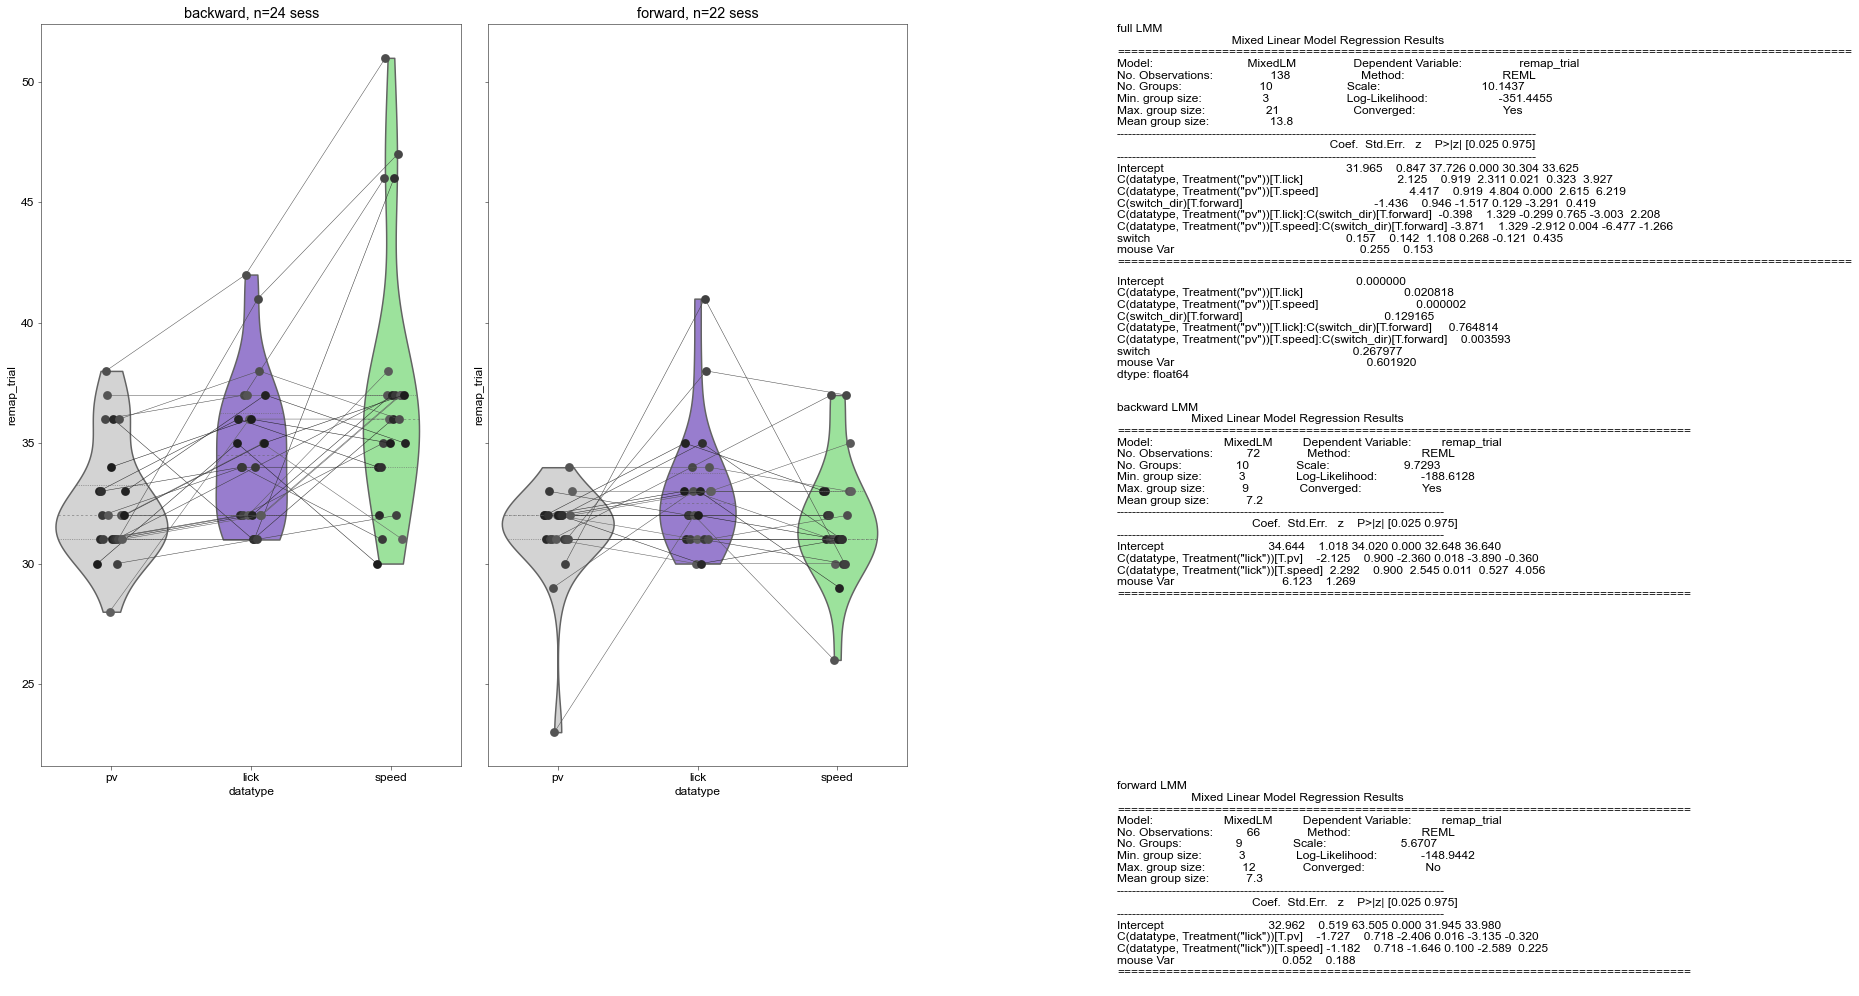

In [164]:
cmap = pt.make_cmap_from_cm(len(include_ans), cmap='Greys_r',
                            cmap_low=0.1, cmap_high=0.3)
# cmap = pt.make_cmap_from_cm(len(include_ans), cmap='tab10',
#                             cmap_low=0, cmap_high=1)
fig, ax = plt.subplots(1, 2, figsize=(28, 14), sharey=True)
style = 'violin'
by = 'session'  # 'session'


if style == 'box':
    sns.boxplot(data=use_df[use_df['switch_dir'] == 'backward'], x='datatype', y='remap_trial',
                ax=ax[0], notch=True, showfliers=False, 
                palette={'pv': 'lightgrey', 'lick': 'mediumpurple', 'speed': 'lightgreen'},
                width=0.7)
    sns.boxplot(data=use_df[use_df['switch_dir'] == 'forward'], x='datatype', y='remap_trial',
                ax=ax[1], notch=True, showfliers=False,  
                palette={'pv': 'lightgrey', 'lick': 'mediumpurple', 'speed': 'lightgreen'},
                width=0.7)
elif style == 'violin':
    sns.violinplot(data=use_df[use_df['switch_dir'] == 'backward'], x='datatype', y='remap_trial',
                   ax=ax[0], inner='quart', cut=0, 
                   palette={'pv': 'lightgrey', 'lick': 'mediumpurple', 'speed': 'lightgreen'})
    sns.violinplot(data=use_df[use_df['switch_dir'] == 'forward'], x='datatype', y='remap_trial',
                   ax=ax[1], inner='quart', cut=0, 
                   palette={'pv': 'lightgrey', 'lick': 'mediumpurple', 'speed': 'lightgreen'})

if by == 'session':
    g = sns.pointplot(data=use_df[use_df['switch_dir'] == 'backward'], 
                      x='datatype', y='remap_trial', ax=ax[0], dodge=0.2,
                      hue='sess_id', palette=cmap)  # hue_order=include_ans)
    g.legend_.remove()
    for line in g.lines:
        line.set_linewidth(0.5)
    g = sns.pointplot(data=use_df[use_df['switch_dir'] == 'forward'], 
                      x='datatype', y='remap_trial', ax=ax[1], dodge=0.2,
                      hue='sess_id', palette=cmap)  # hue_order=include_ans)
    g.legend_.remove()
    for line in g.lines:
        line.set_linewidth(0.5)
elif by == 'mouse':
    g = sns.pointplot(data=use_df[use_df['switch_dir'] == 'backward'], 
                      x='datatype', y='remap_trial', ax=ax[0], dodge=0.2,
                      hue='mouse', palette=cmap, hue_order=include_ans)
    g.legend_.remove()
    g = sns.pointplot(data=use_df[use_df['switch_dir'] == 'forward'], 
                      x='datatype', y='remap_trial', ax=ax[1], dodge=0.2,
                      hue='mouse', palette=cmap, hue_order=include_ans)
    g.legend_.remove()
ax[0].set_title('backward, n=%d sess' %
                (int(len(use_df[use_df['switch_dir'] == 'backward'])/3)))

ax[1].set_title('forward, n=%d sess' %
                (int(len(use_df[use_df['switch_dir'] == 'forward'])/3)))


text_str = 'full LMM \n' + lmm.summary().as_text()

ax[1].text(4, ax[1].get_ylim()[-1], text_str, va='top', ha='left')
ax[1].text(4, ax[1].get_ylim()[-1]-0.2*ax[1].get_ylim()[-1],
           str(lmm.pvalues), va='top', ha='left')
ax[1].text(4, ax[1].get_ylim()[-1]-0.3*ax[1].get_ylim()[-1],
           'backward LMM \n' + lmm_back.summary().as_text(),
           va='top', ha='left')
ax[1].text(4, ax[1].get_ylim()[-1]-0.6*ax[1].get_ylim()[-1],
           'forward LMM \n' + lmm_for.summary().as_text(),
           va='top', ha='left')

save_figures = False
if save_figures:
    if style == 'violin':
        pt.savefig(fig, fig_dir, 
                   'allSwitchAns_days%d-%d_%s_DistScore_RemapTrial-by-switchdir-%sPointPlotViolin' % (
            exp_days[0], exp_days[-1], ct, by),
            extension='.svg')
    elif style == 'box':
        pt.savefig(fig, fig_dir, 
                   'allSwitchAns_days%d-%d_%s_DistScore_RemapTrial-by-switchdir-%sPointPlotBox' % (
            exp_days[0], exp_days[-1], ct, by),
            extension='.svg')

In [165]:
# check nonparametric -- same effects, LMM is more conservative
pingouin.pairwise_ttests(data=rr_df, dv='remap_trial', between='switch_dir', within='datatype', 
                         subject='sess_id', parametric=False,
                         padjust='bonferroni')

,Contrast,datatype,A,B,Paired,Parametric,U-val,W-val,alternative,p-unc,p-corr,p-adjust,hedges
0,datatype,-,lick,pv,True,False,NaN,65.0,two-sided,0.000064,0.000191,bonferroni,0.719713
1,datatype,-,lick,speed,True,False,NaN,250.0,two-sided,0.420141,1.000000,bonferroni,-0.153988
2,datatype,-,pv,speed,True,False,NaN,112.0,two-sided,0.000262,0.000785,bonferroni,-0.656527
3,switch_dir,-,backward,forward,False,False,433.5,NaN,two-sided,0.000195,NaN,NaN,1.113400
4,datatype * switch_dir,lick,backward,forward,False,False,359.5,NaN,two-sided,0.034861,0.104582,bonferroni,0.594706
5,datatype * switch_dir,pv,backward,forward,False,False,315.5,NaN,two-sided,0.247909,0.743727,bonferroni,0.560402
6,datatype * switch_dir,speed,backward,forward,False,False,440.0,NaN,two-sided,0.000100,0.000300,bonferroni,1.203724


### Plot mean licking and speed by switch direction (Ext. Fig. 10a)

Make sure RR cells were run above to get the correct sessions

In [145]:
# consolidate licking and speed from backward and forward sessions included for RR remaps
# to see what they look like relative to reward

# limit it to 1 celltype so we don't double count the sessions
forward_df = sigmoid_df[(sigmoid_df['switch_dir']=='forward') & (sigmoid_df['datatype']=='pv') & (sigmoid_df['ct']=='RR')]
backward_df = sigmoid_df[(sigmoid_df['switch_dir']=='backward') & (sigmoid_df['datatype']=='pv') & (sigmoid_df['ct']=='RR')]
n_forward_sess = int(len(forward_df))
n_backward_sess = int(len(backward_df))
forward_df

,mouse,day,switch,env,ct,sess_id,switch_dir,datatype,remap_trial,diff_lick_pv,diff_speed_pv,lickratio,k,one_map,mainlmm_resid
12,GCAMP12,3,1.0,fam,RR,GCAMP12_3,forward,pv,32.0,NaN,NaN,0.690297,2.0,False,-0.107609
21,GCAMP14,3,1.0,fam,RR,GCAMP14_3,forward,pv,32.0,NaN,NaN,0.486604,2.0,False,-0.924619
30,GCAMP17,3,1.0,fam,RR,GCAMP17_3,forward,pv,31.0,NaN,NaN,0.386984,2.0,False,-0.346611
33,GCAMP18,3,1.0,fam,RR,GCAMP18_3,forward,pv,32.0,NaN,NaN,0.283171,2.0,False,-0.081202
57,GCAMP14,5,2.0,fam,RR,GCAMP14_5,forward,pv,33.0,NaN,NaN,0.797497,2.0,False,-0.178504
66,GCAMP18,5,2.0,fam,RR,GCAMP18_5,forward,pv,31.0,NaN,NaN,0.612753,2.0,False,-1.335086
78,GCAMP3,7,3.0,fam,RR,GCAMP3_7,forward,pv,31.0,NaN,NaN,0.694918,2.0,False,-1.237674
93,GCAMP12,7,3.0,fam,RR,GCAMP12_7,forward,pv,29.0,NaN,NaN,0.620802,2.0,False,-3.615377
120,GCAMP19,7,3.0,fam,RR,GCAMP19_7,forward,pv,23.0,NaN,NaN,0.247256,2.0,False,-9.802217
138,GCAMP11,8,4.0,novel,RR,GCAMP11_8,forward,pv,31.0,NaN,NaN,0.738927,2.0,False,-4.441921


In [146]:
len(forward_df), len(backward_df)

(22, 24)

In [147]:
# taking first 50 trials post-switch only
speed_for = np.zeros((50,
                      multiDayData[3].circ_speed[an]['set 1'][0].shape[1],
                      n_forward_sess))
speed_back = np.zeros((50,
                      multiDayData[3].circ_speed[an]['set 1'][0].shape[1],
                      n_backward_sess))

lick_for = np.zeros((50,
                      multiDayData[3].circ_licks[an]['set 1'].shape[1],
                      n_forward_sess))
lick_back = np.zeros((50,
                      multiDayData[3].circ_licks[an]['set 1'].shape[1],
                      n_backward_sess))


for i,idx in enumerate(forward_df.index):
    end_trial = multiDayData[forward_df.loc[idx, 'day']].circ_speed[forward_df.loc[idx, 'mouse']]['set 1'][0].shape[0]
    if end_trial > 50:
        end_trial = 50
    this_speed = multiDayData[forward_df.loc[idx, 'day']].circ_speed[forward_df.loc[idx, 'mouse']]['set 1'][0][:end_trial,:]
    this_lick = multiDayData[forward_df.loc[idx, 'day']].circ_licks[forward_df.loc[idx, 'mouse']]['set 1'][:end_trial,:]
    
    speed_for[:,:,i][:end_trial,:] = this_speed / np.nanmax(this_speed)
    lick_for[:,:,i][:end_trial,:] = this_lick / np.nanmax(this_lick)
    
for i,idx in enumerate(backward_df.index):
    end_trial = multiDayData[backward_df.loc[idx, 'day']].circ_speed[backward_df.loc[idx, 'mouse']]['set 1'][0].shape[0]
    if end_trial > 50:
        end_trial = 50
    this_speed = multiDayData[backward_df.loc[idx, 'day']].circ_speed[backward_df.loc[idx, 'mouse']]['set 1'][0][:end_trial,:]
    this_lick = multiDayData[backward_df.loc[idx, 'day']].circ_licks[backward_df.loc[idx, 'mouse']]['set 1'][:end_trial,:]
    
    speed_back[:,:,i][:end_trial,:] = this_speed / np.nanmax(this_speed)
    lick_back[:,:,i][:end_trial,:] = this_lick / np.nanmax(this_lick)    

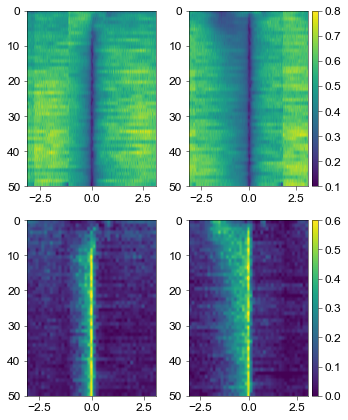

In [148]:

fig,ax = plt.subplots(2,2,figsize=(5,6))

h0=ax[0,0].imshow(np.nanmean(speed_back,axis=2),
                  extent = (multiDayData[3].circ_speed[an]['set 1'][-1][0], # bin edges, can be from any animal and day
                            multiDayData[3].circ_speed[an]['set 1'][-1][-1],
                            50,0),
                  vmin = 0.1,
                  vmax = 0.8,
                  aspect='auto', cmap='viridis')
# pt.colorbar(h0)
h1=ax[0,1].imshow(np.nanmean(speed_for,axis=2),
                  extent = (multiDayData[3].circ_speed[an]['set 1'][-1][0],
                            multiDayData[3].circ_speed[an]['set 1'][-1][-1],
                            50,0),
                  vmin = 0.1,
                  vmax = 0.8,
                  aspect='auto', cmap='viridis')
pt.colorbar(h1)

h2=ax[1,0].imshow(np.nanmean(lick_back,axis=2),
                  extent = (multiDayData[3].circ_trial_matrix[an][-1][0],
                            multiDayData[3].circ_trial_matrix[an][-1][-1],
                            50,0),
                  vmin = 0,
                  vmax = 0.6,
                  aspect='auto', cmap='viridis')
# pt.colorbar(h2)

h3=ax[1,1].imshow(np.nanmean(lick_for,axis=2),
                  extent = (multiDayData[3].circ_trial_matrix[an][-1][0],
                            multiDayData[3].circ_trial_matrix[an][-1][-1],
                            50,0),
                  vmin = 0,
                  vmax = 0.6,
                  aspect='auto', cmap='viridis')
pt.colorbar(h3)

save_figures=False
if save_figures:
    
    pt.savefig(fig, fig_dir, 'allSwitchAns_days%d-%d_%ssess_meanRelSpeedLick_backward-vs-forward' % (
        exp_days[0], exp_days[-1], ct),
               extension='.pdf')